## 📘 Bridebook Data Challenge – Cleaned Code Walkthrough  
## 👤 Author: Raishal Dhawan  
## 🗂️ Structure: Step-by-step with inline comments and grouped logic


## Step 1: Load and explore current data

In [28]:
#Step 1.1: Import libraries
import pandas as pd

## Step 1.2 – Load the 'Current Data' file
# Load the 'Current Data'
current_data = pd.read_csv(r"C:\Users\DELL\Downloads\Challenge Data - Current Data (Candidate) 250324.xlsx - Sheet1.csv")

# Show shape and preview
print("Rows, Columns:", current_data.shape)
current_data.head()

Rows, Columns: (21830, 12)


,SupplierID,SupplierName,Type,SubType,PostalCode,Town,Phone,Website,Email,site_status,redirect_URL,to_be_deleted?
0,BBC00001,1 ON 1 Personal Training,"Beauty, Hair and Make-Up",Health and Fitness,SO18 3NG,Southampton,7792653324,NaN,NaN,NaN,NaN,False
1,BBC00002,100 Percent Glamour,"Beauty, Hair and Make-Up",NaN,WA4 1JJ,Warrington,1925232003,100-glamour.co.uk,NaN,DNS lookup failed,NaN,False
2,BBC00003,"101 Boutique,Thornhill",Wedding Dress and Accessories,Bridalwear,DG3 5LY,Thornhill,1848330740,101boutique.com,barbour@101boutique.com,OK,NaN,False
3,BBC00004,12 Normand Road,Wedding Rings and Jewellery,Jewellery,KY1 2XJ,Kirkcaldy,NaN,NaN,NaN,NaN,NaN,False
4,BBC00005,121 Time,Wedding Rings and Jewellery,Jewellery,SN12 6AG,Melksham,NaN,NaN,NaN,NaN,NaN,False


In [29]:
## Step 1.3 – View data types and structure
# View column names and data types
current_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21830 entries, 0 to 21829
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SupplierID      21830 non-null  object
 1   SupplierName    21830 non-null  object
 2   Type            21830 non-null  object
 3   SubType         18364 non-null  object
 4   PostalCode      21830 non-null  object
 5   Town            21103 non-null  object
 6   Phone           18414 non-null  object
 7   Website         16682 non-null  object
 8   Email           11821 non-null  object
 9   site_status     15944 non-null  object
 10  redirect_URL    6367 non-null   object
 11  to_be_deleted?  21830 non-null  bool  
dtypes: bool(1), object(11)
memory usage: 1.9+ MB


In [30]:
## Step 1.4 – Check for exact duplicate rows
duplicate_rows = current_data[current_data.duplicated()]
print(f"Duplicate Rows Found: {len(duplicate_rows)}")

Duplicate Rows Found: 0


In [31]:
## Step 1.5 – View missing values
# Total missing values per column
current_data.isnull().sum()

SupplierID            0
SupplierName          0
Type                  0
SubType            3466
PostalCode            0
Town                727
Phone              3416
Website            5148
Email             10009
site_status        5886
redirect_URL      15463
to_be_deleted?        0
dtype: int64

In [32]:
## Step 1.6 – Basic frequency analysis of key fields
current_data['Type'].value_counts()
current_data['Website'].value_counts().head(10)

Website
shoezone.com         296
hsamuel.co.uk        277
ernestjones.co.uk    152
clarks.co.uk         108
moss.co.uk            95
fhinds.co.uk          91
warrenjames.co.uk     78
brantano.co.uk        77
goldsmiths.co.uk      75
tie-rack.co.uk        63
Name: count, dtype: int64

## Step 2: Clean and prepare current data

In [33]:
## Step 2.1 – Copy and clean key columns (lowercase, strip)

# Make a copy to preserve raw data
cleaned_data = current_data.copy()

# Strip whitespace and lowercase key fields
for col in ['SupplierName', 'Website', 'Email', 'Town', 'Phone', 'PostalCode']:
    cleaned_data[col] = cleaned_data[col].astype(str).str.strip().str.lower()

## Step 2.2 – Normalize Website format

# Normalize website format (remove http, https, www, trailing slashes)
cleaned_data['Website'] = (
    cleaned_data['Website']
    .str.replace(r'^https?:\/\/(www\.)?', '', regex=True)
    .str.replace(r'^www\.', '', regex=True)
    .str.replace(r'\/$', '', regex=True)
)

# Preview cleaned columns
cleaned_data[['SupplierName', 'Website', 'Email']].head(10)

,SupplierName,Website,Email
0,1 on 1 personal training,nan,nan
1,100 percent glamour,100-glamour.co.uk,nan
2,"101 boutique,thornhill",101boutique.com,barbour@101boutique.com
3,12 normand road,nan,nan
4,121 time,nan,nan
5,130 dermal spa,130dermalspa.com,paul@13dermalspa.com
6,14 & sixpence,14andsixpence.co.uk,mail@14andsixpence.co.uk
7,15 royal terrace day spa,15royalterrace.co.uk,relax@15royalterrace.co.uk
8,1791 diamonds,1791diamonds.co.uk,customerservices@1791diamonds.com
9,18 dental,18dental.com,info@18dental.com


In [34]:
## Step 2.3 – Check common duplicate patterns

# Count how many times each website appears
website_dupes = cleaned_data['Website'].value_counts()
email_dupes = cleaned_data['Email'].value_counts()

# Show repeated websites
print("Websites with more than 1 occurrence:")
print(website_dupes[website_dupes > 1].head(10))

# Show repeated emails
print("\nEmails with more than 1 occurrence:")
print(email_dupes[email_dupes > 1].head(10))


Websites with more than 1 occurrence:
Website
nan                  5148
shoezone.com          296
hsamuel.co.uk         278
ernestjones.co.uk     152
clarks.co.uk          108
moss.co.uk             95
fhinds.co.uk           91
warrenjames.co.uk      78
brantano.co.uk         77
goldsmiths.co.uk       75
Name: count, dtype: int64

Emails with more than 1 occurrence:
Email
nan                                      10009
customerservices@shoezone.com              346
customer.services@ernestjones.co.uk        101
customercare@clarks.com                     79
onlinesales@fhinds.co.uk                    69
customer.services@hsamuel.co.uk             63
info@timpson.co.uk                          57
webenquiries@goldsmiths.co.uk               51
info@greenwoodsonline.com                   48
customerservices@thetanningshop.co.uk       48
Name: count, dtype: int64


In [35]:
## Step 2.4 – Investigate sample duplicate website rows

# Get rows with top 5 duplicate websites
top_websites = website_dupes[website_dupes > 1].head(5).index
duplicate_website_rows = cleaned_data[cleaned_data['Website'].isin(top_websites)]

# View them to assess duplication risk
duplicate_website_rows.sort_values('Website').head(20)


,SupplierID,SupplierName,Type,SubType,PostalCode,Town,Phone,Website,Email,site_status,redirect_URL,to_be_deleted?
19055,BBC19056,"the clarks, london",Wedding Dress and Accessories,Shoes,w1c 1ld,london,8444999032,clarks.co.uk,info@clarks.co.uk,OK,NaN,False
18951,BBC18952,"the clarks factory shop, blackpool",Wedding Dress and Accessories,Shoes,fy4 4uj,blackpool,1253699380,clarks.co.uk,nan,OK,NaN,False
18952,BBC18953,"the clarks factory shop, bridgend",Wedding Dress and Accessories,Shoes,ba16 0eq,street,1458899901,clarks.co.uk,customercare@clarks.com,OK,NaN,False
18954,BBC18955,"the clarks factory shop, dewsbury",Wedding Dress and Accessories,Shoes,wf12 8eq,dewsbury,1924430444,clarks.co.uk,customercare@clarks.com,OK,NaN,False
18956,BBC18957,"the clarks factory shop, murton seaham",Wedding Dress and Accessories,Shoes,sr7 9hu,murton,1915172777,clarks.co.uk,customer.care@clarks.in,OK,NaN,False
18959,BBC18960,"the clarks shoe dept, slough",Wedding Dress and Accessories,Shoes,ba16 0eq,street,1458899901,clarks.co.uk,customercare@clarks.com,OK,NaN,False
18960,BBC18961,"the clarks shoe dept, solihull",Wedding Dress and Accessories,Shoes,ba16 0eq,street,1458899901,clarks.co.uk,customercare@clarks.com,OK,NaN,False
18962,BBC18963,"the clarks shoe, wirral",Wedding Dress and Accessories,Shoes,ch62 3pn,birkenhead,1458899901,clarks.co.uk,customercare@clarks.com,OK,NaN,False
18964,BBC18965,"the clarks shop, aberystwyth",Wedding Dress and Accessories,Shoes,sy23 1de,aberystwyth,1970615590,clarks.co.uk,nan,OK,NaN,False
18965,BBC18966,"the clarks shop, altrincham",Wedding Dress and Accessories,Shoes,wa14 1rj,altrincham,1458899901,clarks.co.uk,customercare@clarks.com,OK,NaN,False


In [36]:
## Step 2.5 – Group by Parent Brand (same Website)

# Add ParentBrand column to identify brand clusters
cleaned_data['ParentBrand'] = cleaned_data['Website']

# Optional: fill NaN in ParentBrand with SupplierName if Website missing
cleaned_data['ParentBrand'] = cleaned_data['ParentBrand'].fillna(cleaned_data['SupplierName'])

# Preview grouped brands
cleaned_data[['SupplierName', 'Website', 'ParentBrand']].head(10)


,SupplierName,Website,ParentBrand
0,1 on 1 personal training,nan,nan
1,100 percent glamour,100-glamour.co.uk,100-glamour.co.uk
2,"101 boutique,thornhill",101boutique.com,101boutique.com
3,12 normand road,nan,nan
4,121 time,nan,nan
5,130 dermal spa,130dermalspa.com,130dermalspa.com
6,14 & sixpence,14andsixpence.co.uk,14andsixpence.co.uk
7,15 royal terrace day spa,15royalterrace.co.uk,15royalterrace.co.uk
8,1791 diamonds,1791diamonds.co.uk,1791diamonds.co.uk
9,18 dental,18dental.com,18dental.com


## Load and clean directory scrape data

In [37]:
## Step 3.1 – Load scraped data

# Load scraped data
scraped_data = pd.read_csv(r"C:\Users\DELL\Downloads\Challenge Data - Directory Scrape (Candidate) 250324.xlsx - Sheet1.csv")

# Quick preview
print("Shape:", scraped_data.shape)
scraped_data.head()


Shape: (4079, 7)


,0. Index,1. Category,2. Name,3. Post Code,4. County,5. Website,6. Phone Number
0,0,Jewellery and Wedding Rings,Dorus Mhor,SW11 5AQ,Greater London,dorusmhor.com,NaN
1,1,Jewellery and Wedding Rings,Denton and Grace,N14 6NG,Greater London,plus.google.com/117492567548423419793,7743487434
2,2,Beauty - Hair and Make-Up,Space,GU34 1SA,Hampshire,spa-ce.co.uk,142087575
3,3,Wedding Dresses and Accessories,Grace Bardin Bespoke Bridal Wear,CM21 9JX,Hertfordshire,NaN,7887708744
4,4,Beauty - Hair and Make-Up,Headquarters,KT24 6QN,Surrey,NaN,1483284258


In [38]:
## Step 3.2 – Rename columns to match current data

# Rename columns using exact matches
scraped_data.rename(columns={
    '2. Name': 'SupplierName',
    '1. Category': 'Type',
    '3. Post Code': 'PostalCode',
    '4. County': 'Town',
    '6. Phone Number': 'Phone',
    '5. Website': 'Website'
}, inplace=True)

## Step 3.3 – Clean and normalize

# Clean text fields
for col in ['SupplierName', 'Website', 'Phone', 'PostalCode', 'Town']:
    scraped_data[col] = scraped_data[col].astype(str).str.strip().str.lower()

# Normalize website format
scraped_data['Website'] = (
    scraped_data['Website']
    .str.replace(r'^https?:\/\/(www\.)?', '', regex=True)
    .str.replace(r'^www\.', '', regex=True)
    .str.replace(r'\/$', '', regex=True)
)

# Create ParentBrand
scraped_data['ParentBrand'] = scraped_data['Website']
scraped_data['ParentBrand'] = scraped_data['ParentBrand'].fillna(scraped_data['SupplierName'])

# Preview cleaned scraped data
scraped_data[['SupplierName', 'Website', 'ParentBrand']].head()




,SupplierName,Website,ParentBrand
0,dorus mhor,dorusmhor.com,dorusmhor.com
1,denton and grace,plus.google.com/117492567548423419793,plus.google.com/117492567548423419793
2,space,spa-ce.co.uk,spa-ce.co.uk
3,grace bardin bespoke bridal wear,nan,nan
4,headquarters,nan,nan


In [39]:
print(scraped_data.columns.tolist())


['0. Index', 'Type', 'SupplierName', 'PostalCode', 'Town', 'Website', 'Phone', 'ParentBrand']


## Step 4: Merge and Duplicate

In [40]:
## Step 4.1 – Create match key

# Match key for cleaned current data
cleaned_data['MatchKey'] = cleaned_data['Website']
cleaned_data['MatchKey'] = cleaned_data['MatchKey'].fillna(cleaned_data['SupplierName'])

# Match key for scraped data
scraped_data['MatchKey'] = scraped_data['Website']
scraped_data['MatchKey'] = scraped_data['MatchKey'].fillna(scraped_data['SupplierName'])


In [41]:
## Step 4.2 – Filter out duplicates from scrape

# Identify which scraped MatchKeys are already present
existing_keys = cleaned_data['MatchKey'].unique()

# Filter scraped data to only include new suppliers
scraped_unique = scraped_data[~scraped_data['MatchKey'].isin(existing_keys)]

# Check how many are truly new
print(f"Unique new suppliers from scrape: {scraped_unique.shape[0]}")


Unique new suppliers from scrape: 1899


In [42]:
## Step 4.3 – Align column structure

# Align column structure
columns_to_keep = ['SupplierName', 'Type', 'PostalCode', 'Town', 'Phone', 'Website', 'ParentBrand']

# Add missing columns to scraped_unique (to match current data structure)
for col in columns_to_keep:
    if col not in scraped_unique.columns:
        scraped_unique[col] = None

# Add placeholder columns for scraped data (not available there)
scraped_unique['Email'] = None
scraped_unique['site_status'] = None
scraped_unique['redirect_URL'] = None
scraped_unique['to_be_deleted?'] = False

# Final column order (same as cleaned_data)
final_columns = ['SupplierName', 'Type', 'SubType', 'PostalCode', 'Town', 'Phone', 'Website',
                 'Email', 'site_status', 'redirect_URL', 'to_be_deleted?', 'ParentBrand']

# Add missing columns to scraped_unique
for col in final_columns:
    if col not in scraped_unique.columns:
        scraped_unique[col] = None

# Ensure current data has all final columns too
for col in final_columns:
    if col not in cleaned_data.columns:
        cleaned_data[col] = None

# Combine both
merged_data = pd.concat([cleaned_data[final_columns], scraped_unique[final_columns]], ignore_index=True)

# Final shape
print("Final combined shape:", merged_data.shape)

# Preview
merged_data.head()


Final combined shape: (23729, 12)


C:\Users\DELL\AppData\Local\Temp\ipykernel_13304\3376154423.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scraped_unique['Email'] = None
C:\Users\DELL\AppData\Local\Temp\ipykernel_13304\3376154423.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scraped_unique['site_status'] = None
C:\Users\DELL\AppData\Local\Temp\ipykernel_13304\3376154423.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

,SupplierName,Type,SubType,PostalCode,Town,Phone,Website,Email,site_status,redirect_URL,to_be_deleted?,ParentBrand
0,1 on 1 personal training,"Beauty, Hair and Make-Up",Health and Fitness,so18 3ng,southampton,7792653324,nan,nan,NaN,NaN,False,nan
1,100 percent glamour,"Beauty, Hair and Make-Up",NaN,wa4 1jj,warrington,1925232003,100-glamour.co.uk,nan,DNS lookup failed,NaN,False,100-glamour.co.uk
2,"101 boutique,thornhill",Wedding Dress and Accessories,Bridalwear,dg3 5ly,thornhill,1848330740,101boutique.com,barbour@101boutique.com,OK,NaN,False,101boutique.com
3,12 normand road,Wedding Rings and Jewellery,Jewellery,ky1 2xj,kirkcaldy,nan,nan,nan,NaN,NaN,False,nan
4,121 time,Wedding Rings and Jewellery,Jewellery,sn12 6ag,melksham,nan,nan,nan,NaN,NaN,False,nan


## Final QA checks and output

In [43]:
## Step 5.1 – Check for duplicated websites/emails

# Check for duplicated websites
dupe_websites = merged_data[merged_data.duplicated('Website', keep=False) & merged_data['Website'].notna()]
print("Duplicated Websites:", dupe_websites['Website'].nunique())

# Check for duplicated emails
dupe_emails = merged_data[merged_data.duplicated('Email', keep=False) & merged_data['Email'].notna()]
print("Duplicated Emails:", dupe_emails['Email'].nunique())


Duplicated Websites: 790
Duplicated Emails: 608


In [44]:
## Step 5.2 – Missing values summary

# Summary of missing values
missing_summary = merged_data.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing_summary)


Missing values per column:
redirect_URL      17362
site_status        7785
SubType            5365
Email              1899
SupplierName          0
Type                  0
PostalCode            0
Town                  0
Phone                 0
Website               0
to_be_deleted?        0
ParentBrand           0
dtype: int64


In [45]:
## Step 5.3 – Save to CSV

# Save to CSV
merged_data.to_csv("bridebook_cleaned_merged_data.csv", index=False)
print("Saved as bridebook_cleaned_merged_data.csv")


Saved as bridebook_cleaned_merged_data.csv


## Step 6: Reporting & Bonus Enhancements

In [46]:
## Summary Snapshot

print("Total suppliers:", len(merged_data))
print("Unique websites:", merged_data['Website'].nunique())
print("Missing emails:", merged_data['Email'].isna().sum())
print("Suppliers grouped under shared ParentBrand:", merged_data['ParentBrand'].nunique())


Total suppliers: 23729
Unique websites: 15232
Missing emails: 1899
Suppliers grouped under shared ParentBrand: 15232


In [47]:
## Optional: Reusable cleaning function

def clean_supplier_data(df):
    df = df.copy()
    for col in ['SupplierName', 'Website', 'Phone', 'PostalCode', 'Town']:
        df[col] = df[col].astype(str).str.strip().str.lower()
    df['Website'] = (
        df['Website']
        .str.replace(r'^https?:\/\/(www\.)?', '', regex=True)
        .str.replace(r'^www\.', '', regex=True)
        .str.replace(r'\/$', '', regex=True)
    )
    df['ParentBrand'] = df['Website'].fillna(df['SupplierName'])
    df['MatchKey'] = df['Website'].fillna(df['SupplierName'])
    return df


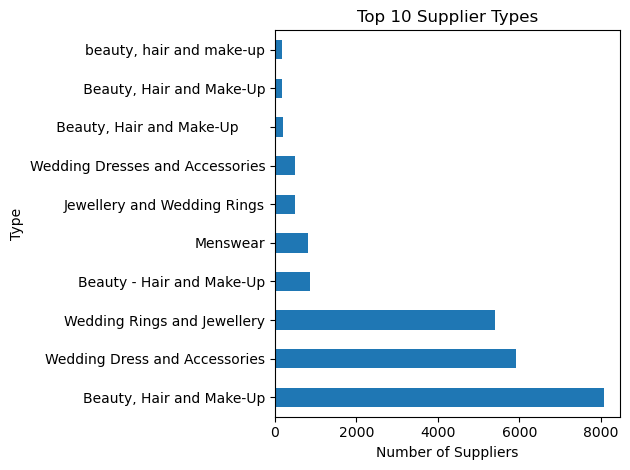

In [48]:
## Optional: Visualize top supplier types

import matplotlib.pyplot as plt

merged_data['Type'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Supplier Types")
plt.xlabel("Number of Suppliers")
plt.tight_layout()
plt.show()
